1. Frequency Analysis - 어느정도 reportable한 거를 만들어 놔야함
일단 전체로 해서 그냥 눈으로 비교해보기
Raw 신호분석: sENG / sEMG / iENG
- Gesture 단위
- FFT돌리기
- 채널들 값 합쳐서 평균시키기
- Spectral features
참고: 여기서 feature는 의미없음
Spectral Feature Methods - Instead of just visualizing the spectrum, you can extract features that summarize it:
- Power Spectral Density (PSD): Gives power distribution across frequencies. Common in EMG to quantify muscle fatigue (shift toward lower frequencies).
- Median/Mean Frequency: Simple spectral features derived from PSD. Useful for EMG fatigue detection or comparing ENG conduction velocities.
- Frequency Band Ratios: E.g., ratio of high-frequency to low-frequency content.
- Spectral Moments: Mean, variance, skewness, and kurtosis of the spectrum. Useful for characterizing signal complexity.

# sENG

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import scipy

In [16]:
def call_dataset(path, modality, session):
    if modality=='EMG':
        bluetooth_id = 'E8DD80E550BB'
    elif modality=='ENG':
        bluetooth_id = 'E9AD0E7DCC2B'
    else:
        print("modality must be EMG or ENG")

    dataset = []
    data_per_class_files = os.listdir(path+f'{modality}_{session}/{bluetooth_id}/raw/')
    for cls in data_per_class_files:
        input_path = path+f'{modality}_{session}/{bluetooth_id}/raw/{cls}/'
        files = os.listdir(input_path)
        mat = scipy.io.loadmat(input_path+files[0])
        #dict_keys(['__header__', '__version__', '__globals__', 'Data_ADC', 'Data_Cls', 'Data_Fea', 'Dev_Channels', 'Dev_Info', 'Dev_NCh'])
        dataset.append(mat)

    return dataset

In [17]:
path = 'C:/Users/hml76/PycharmProjects/MindForce/data/EMG_ENG/Hunmin/'

EMG_all_Subject1 = call_dataset(path, modality='EMG', session='v1')
ENG_all_Subject1 = call_dataset(path, modality='ENG', session='v1')S

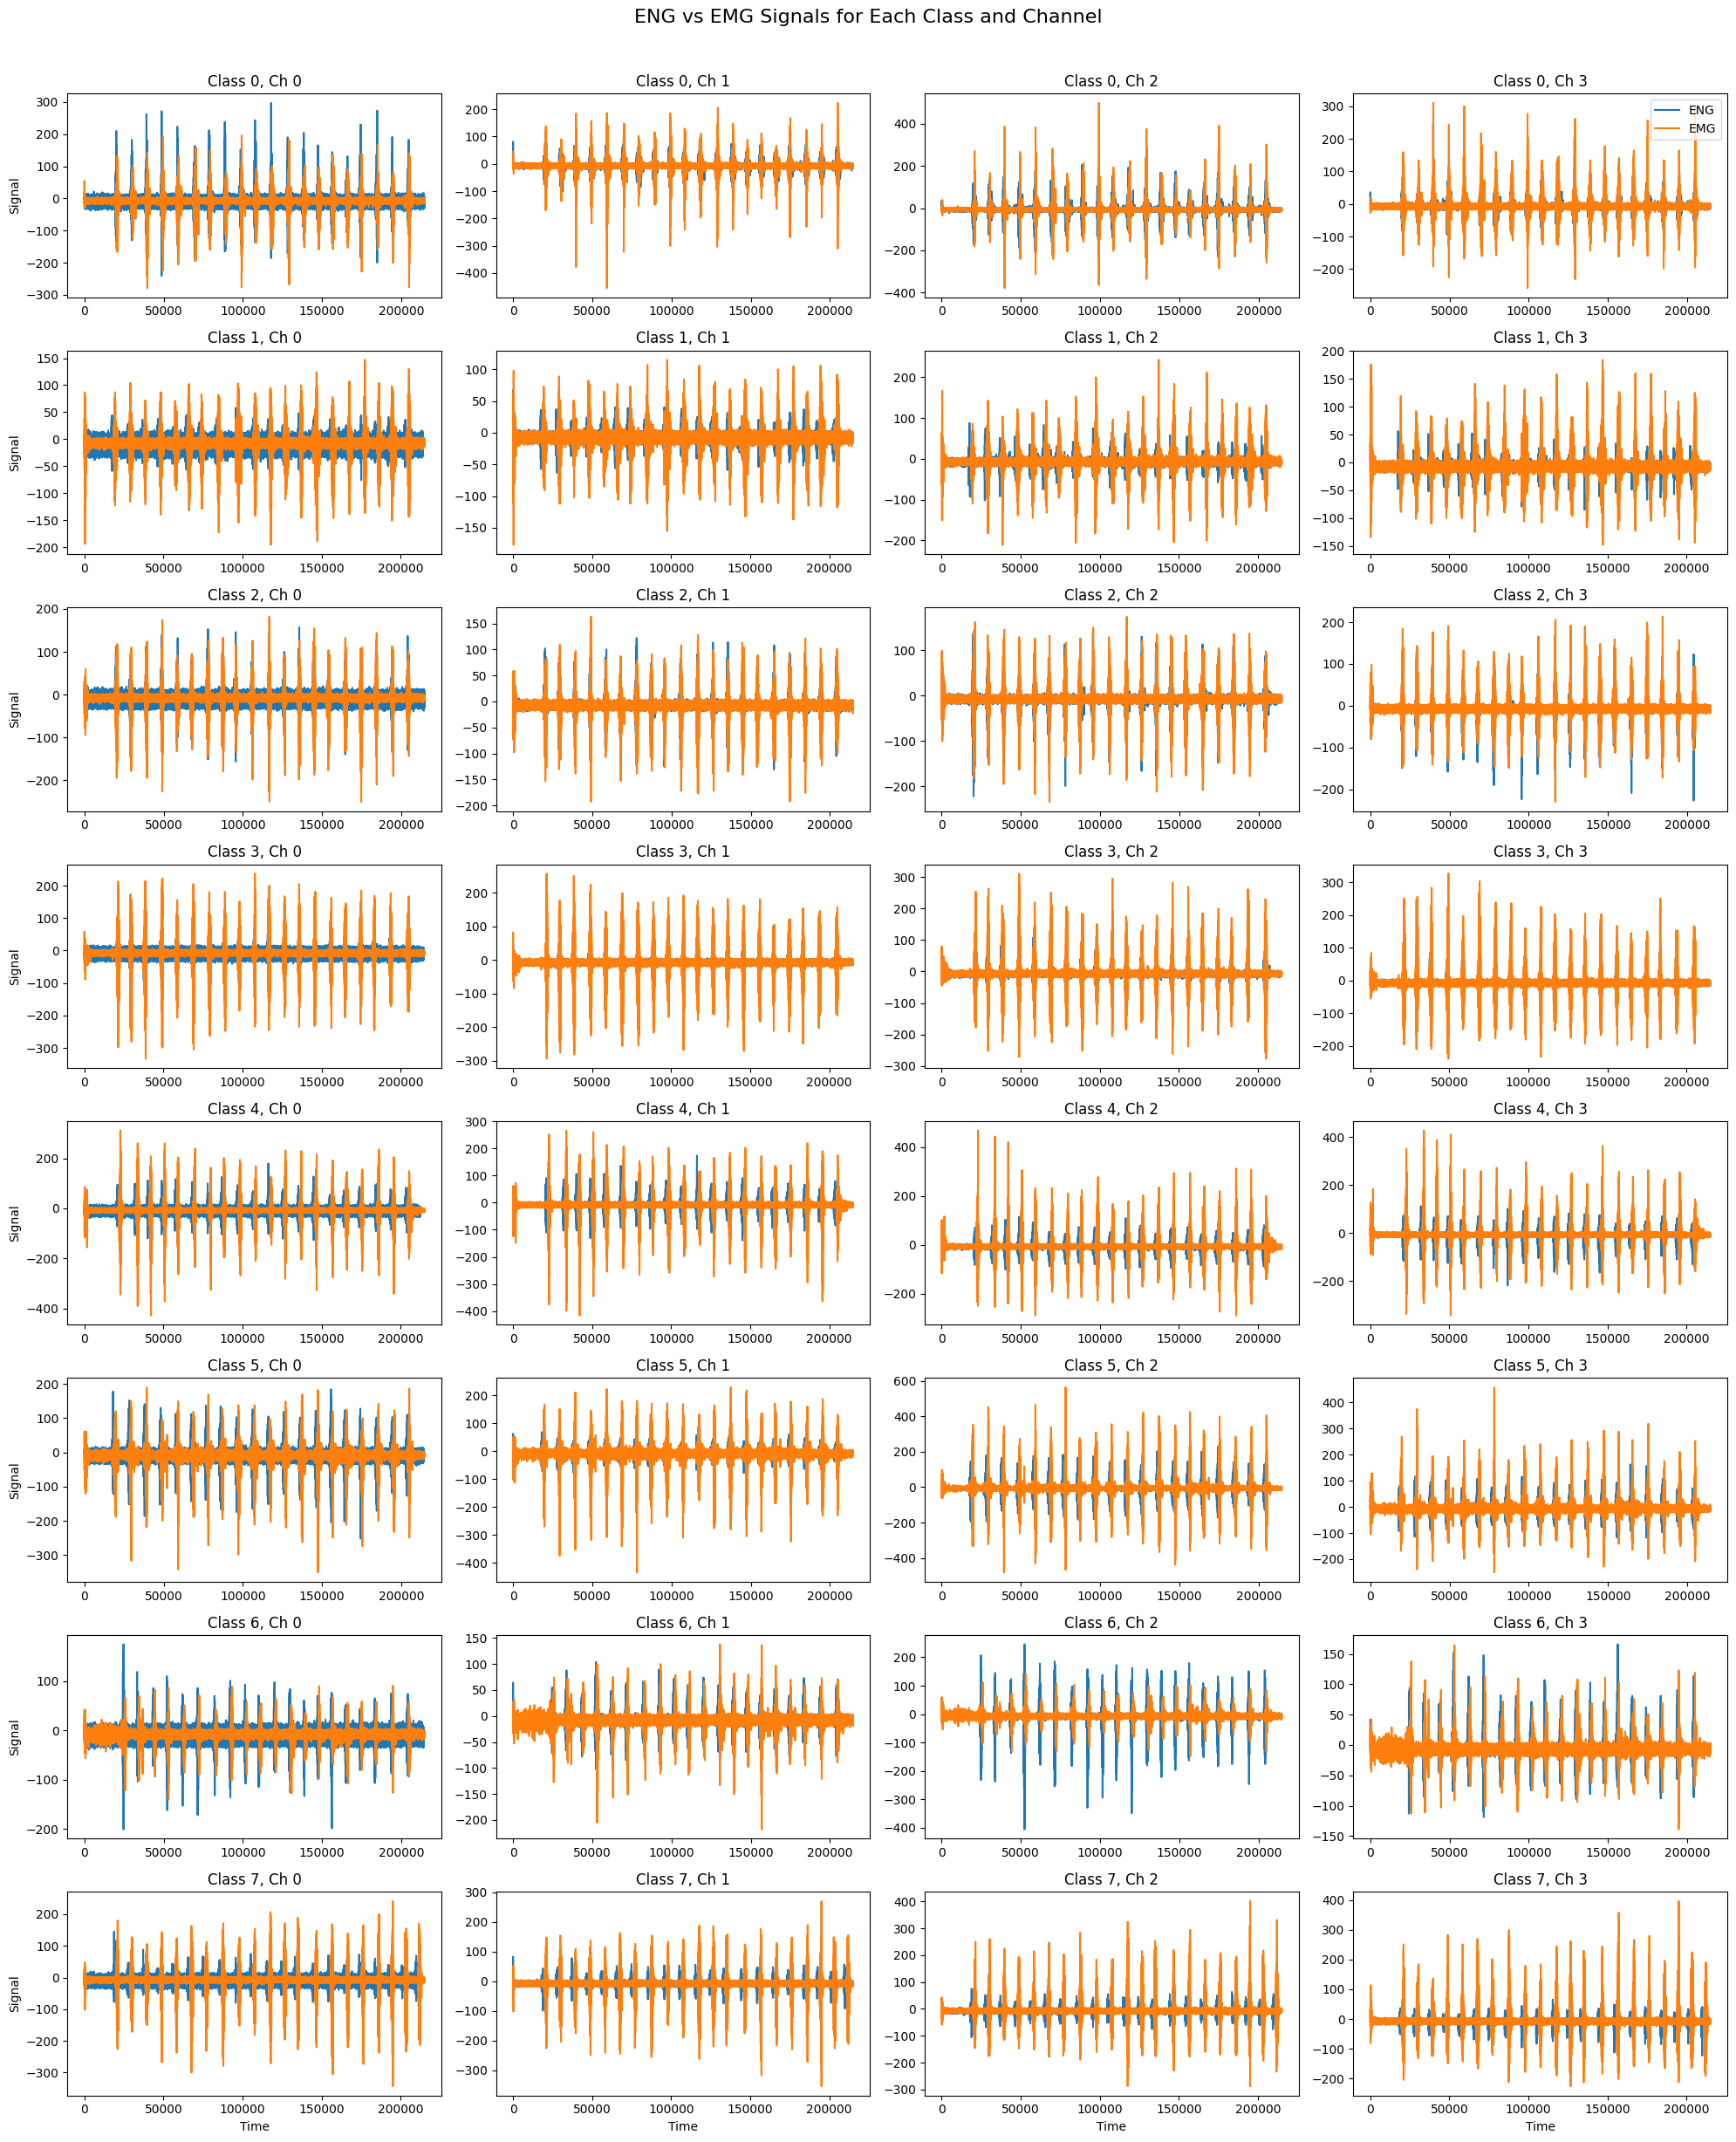

In [26]:
import matplotlib.pyplot as plt

num_classes = 8  # cls 0 to 7

# Determine number of channels dynamically (from first class)
num_channels = min(len(ENG_all[0]['Data_ADC']), len(EMG_all[0]['Data_ADC']))

fig, axes = plt.subplots(num_classes, num_channels, figsize=(20, 25)) #, sharex=True, sharey=True
fig.suptitle('ENG vs EMG Signals for Each Class and Channel', fontsize=16)

for cls in range(num_classes):
    for ch in range(num_channels):
        ax = axes[cls, ch]
        ax.plot(ENG_all[cls]['Data_ADC'][ch], label='ENG')
        ax.plot(EMG_all[cls]['Data_ADC'][ch], label='EMG')
        ax.set_title(f'Class {cls}, Ch {ch}')
        if cls == num_classes-1:
            ax.set_xlabel('Time')
        if ch == 0:
            ax.set_ylabel('Signal')
        if cls == 0 and ch == num_channels-1:
            ax.legend(loc='upper right')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

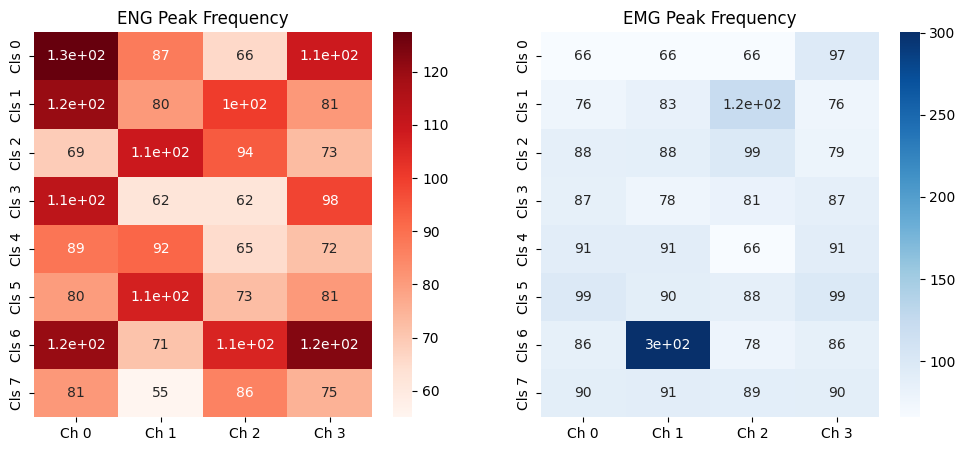

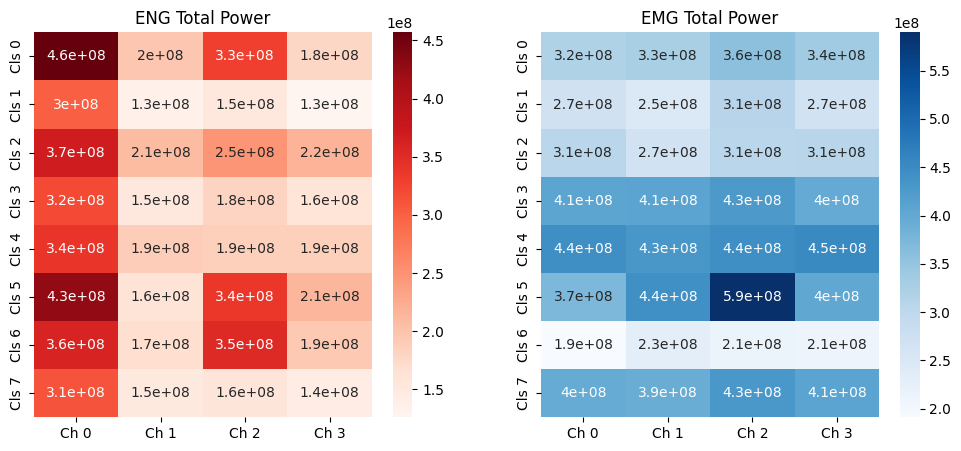

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sampling rate
fs = round(10e6 / 2048)

num_classes = 8
num_channels = min(len(ENG_all[0]['Data_ADC']), len(EMG_all[0]['Data_ADC']))

# Initialize arrays to store peak frequency and total power
eng_peak_freq = np.zeros((num_classes, num_channels))
emg_peak_freq = np.zeros((num_classes, num_channels))
eng_total_power = np.zeros((num_classes, num_channels))
emg_total_power = np.zeros((num_classes, num_channels))

for cls in range(num_classes):
    for ch in range(num_channels):
        # Remove DC offset
        eng_signal = ENG_all[cls]['Data_ADC'][ch] - np.mean(ENG_all[cls]['Data_ADC'][ch])
        emg_signal = EMG_all[cls]['Data_ADC'][ch] - np.mean(EMG_all[cls]['Data_ADC'][ch])

        # FFT for ENG
        eng_fft = np.fft.fft(eng_signal)
        n_eng = len(eng_signal)
        freqs_eng = np.fft.fftfreq(n_eng, d=1/fs)
        eng_pos_mask = freqs_eng > 0  # ignore 0 Hz now
        eng_fft_mag = np.abs(eng_fft[eng_pos_mask])
        freqs_eng = freqs_eng[eng_pos_mask]

        # FFT for EMG
        emg_fft = np.fft.fft(emg_signal)
        n_emg = len(emg_signal)
        freqs_emg = np.fft.fftfreq(n_emg, d=1/fs)
        emg_pos_mask = freqs_emg > 0  # ignore 0 Hz
        emg_fft_mag = np.abs(emg_fft[emg_pos_mask])
        freqs_emg = freqs_emg[emg_pos_mask]

        # Peak frequency
        eng_peak_freq[cls, ch] = freqs_eng[np.argmax(eng_fft_mag)]
        emg_peak_freq[cls, ch] = freqs_emg[np.argmax(emg_fft_mag)]

        # Total power (excluding DC)
        eng_total_power[cls, ch] = np.sum(eng_fft_mag)
        emg_total_power[cls, ch] = np.sum(emg_fft_mag)

# --- Visualization ---
# Heatmap of peak frequency
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(eng_peak_freq, annot=True, cmap='Reds', xticklabels=[f'Ch {i}' for i in range(num_channels)],
            yticklabels=[f'Cls {i}' for i in range(num_classes)])
plt.title('ENG Peak Frequency')
plt.subplot(1,2,2)
sns.heatmap(emg_peak_freq, annot=True, cmap='Blues', xticklabels=[f'Ch {i}' for i in range(num_channels)],
            yticklabels=[f'Cls {i}' for i in range(num_classes)])
plt.title('EMG Peak Frequency')
plt.show()

# Heatmap of total power
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(eng_total_power, annot=True, cmap='Reds', xticklabels=[f'Ch {i}' for i in range(num_channels)],
            yticklabels=[f'Cls {i}' for i in range(num_classes)])
plt.title('ENG Total Power')
plt.subplot(1,2,2)
sns.heatmap(emg_total_power, annot=True, cmap='Blues', xticklabels=[f'Ch {i}' for i in range(num_channels)],
            yticklabels=[f'Cls {i}' for i in range(num_classes)])
plt.title('EMG Total Power')
plt.show()

# FFT result

- Subject-wise aggregation
- EMG vs ENG during simultaneous collection
-


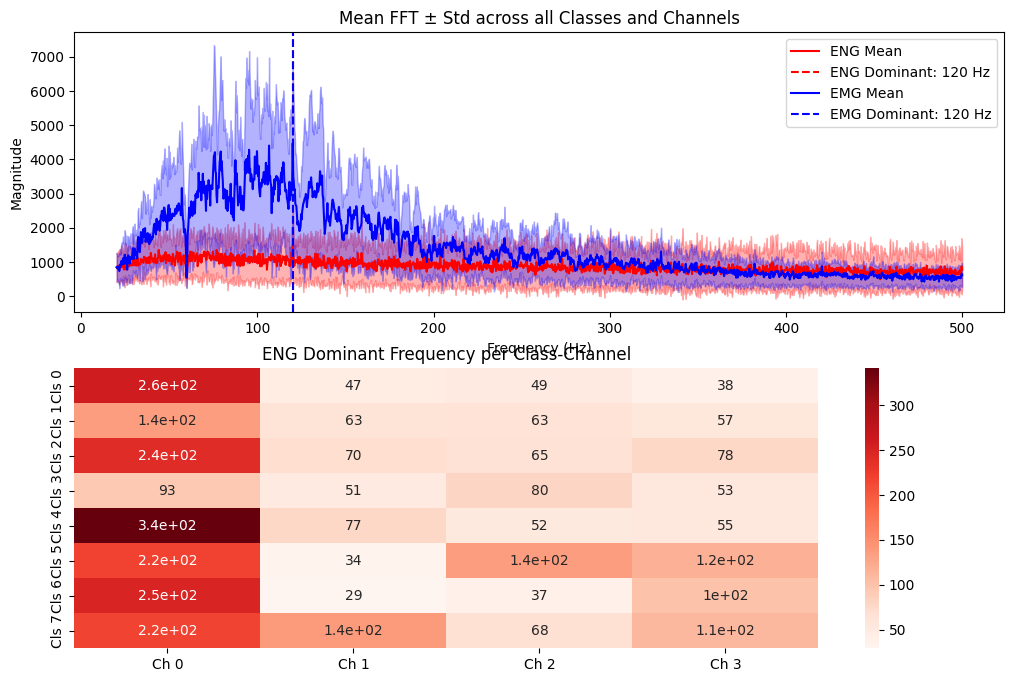

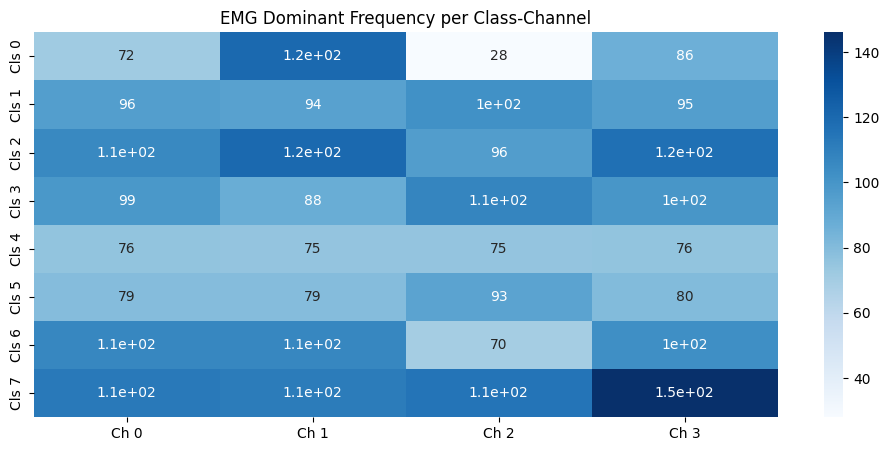

In [36]:
import numpy as np
import matplotlib.pyplot as plt

fs = round(10e6 / 2048)
num_classes = 8
num_channels = min(len(ENG_all[0]['Data_ADC']), len(EMG_all[0]['Data_ADC']))

freq_min, freq_max = 20, 500
num_bins = 100  # 밴드 해상도 증가

# Prepare figure
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

for signal_type, color in zip(['ENG', 'EMG'], ['red', 'blue']):
    # Store all FFTs
    all_fft_mag = []

    for cls in range(num_classes):
        for ch in range(num_channels):
            signal = ENG_all[cls]['Data_ADC'][ch] if signal_type=='ENG' else EMG_all[cls]['Data_ADC'][ch]
            signal = signal - np.mean(signal)  # DC 제거

            n = len(signal)
            fft_vals = np.fft.fft(signal, n=2**14)  # zero-padding to 16384 for better freq resolution
            freqs = np.fft.fftfreq(len(fft_vals), d=1/fs)
            pos_mask = (freqs > 0) & (freqs >= freq_min) & (freqs <= freq_max)
            fft_mag = np.abs(fft_vals[pos_mask])
            freqs = freqs[pos_mask]

            all_fft_mag.append(fft_mag)

    all_fft_mag = np.array(all_fft_mag)
    mean_fft = np.mean(all_fft_mag, axis=0)
    std_fft = np.std(all_fft_mag, axis=0)

    # Dominant band (peak of mean spectrum)
    dom_idx = np.argmax(mean_fft)
    dom_freq = freqs[dom_idx]

    axes[0].plot(freqs, mean_fft, label=f'{signal_type} Mean', color=color)
    axes[0].fill_between(freqs, mean_fft-std_fft, mean_fft+std_fft, color=color, alpha=0.3)
    axes[0].axvline(dom_freq, color=color, linestyle='--', label=f'{signal_type} Dominant: {int(dom_freq)} Hz')

axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Magnitude')
axes[0].set_title('Mean FFT ± Std across all Classes and Channels')
axes[0].legend()

# Dominant frequency for each class-channel as heatmap
eng_dom_band = []
emg_dom_band = []
for cls in range(num_classes):
    eng_row = []
    emg_row = []
    for ch in range(num_channels):
        eng_signal = ENG_all[cls]['Data_ADC'][ch] - np.mean(ENG_all[cls]['Data_ADC'][ch])
        emg_signal = EMG_all[cls]['Data_ADC'][ch] - np.mean(EMG_all[cls]['Data_ADC'][ch])

        eng_fft = np.fft.fft(eng_signal, n=2**14)
        emg_fft = np.fft.fft(emg_signal, n=2**14)
        freqs = np.fft.fftfreq(len(eng_fft), d=1/fs)
        pos_mask = (freqs > 0) & (freqs >= freq_min) & (freqs <= freq_max)

        eng_fft_mag = np.abs(eng_fft[pos_mask])
        emg_fft_mag = np.abs(emg_fft[pos_mask])
        freqs = freqs[pos_mask]

        eng_row.append(freqs[np.argmax(eng_fft_mag)])
        emg_row.append(freqs[np.argmax(emg_fft_mag)])
    eng_dom_band.append(eng_row)
    emg_dom_band.append(emg_row)

# Heatmaps
import seaborn as sns
plt.subplot(2,1,2)
sns.heatmap(eng_dom_band, annot=True, cmap='Reds', xticklabels=[f'Ch {i}' for i in range(num_channels)],
            yticklabels=[f'Cls {i}' for i in range(num_classes)])
plt.title('ENG Dominant Frequency per Class-Channel')
plt.show()

plt.figure(figsize=(12,5))
sns.heatmap(emg_dom_band, annot=True, cmap='Blues', xticklabels=[f'Ch {i}' for i in range(num_channels)],
            yticklabels=[f'Cls {i}' for i in range(num_classes)])
plt.title('EMG Dominant Frequency per Class-Channel')
plt.show()
